
0. сделать функцию отображенитя результата
1. Посчитать mean и std для аугментаций
2. сделать бейслайн без skip-connections
3. сделать transfer-learning для U-Net


# Data download + Classes

## Download

In [1]:
import os
import random
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files, runtime, drive


from sklearn.model_selection import train_test_split

from tqdm import tqdm

from PIL import Image

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet34, ResNet34_Weights
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.modules.loss import BCEWithLogitsLoss, CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)


seed_everything(42)

Using device: cpu


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
full_dataset = OxfordIIITPet(root='./data', split='trainval', target_types='segmentation', download=True)
full_test_dataset = OxfordIIITPet(root='./data', split='test', target_types='segmentation')

train_indecies, val_indecies = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_transform = None # A.Compose([
#     A.Resize(256, 256),
#     A.HorizontalFlip(p=0.5),
#     A.Rotate(limit=15, p=0.5),
#     A.ColorJitter(p=0.3),
#     A.Normalize(
#         mean=(0.485, 0.456, 0.406),
#         std=(0.229, 0.224, 0.225)
#     ),
#     ToTensorV2()
# ])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

100%|██████████| 792M/792M [00:18<00:00, 42.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 15.1MB/s]


## Classes

In [4]:
class OxfordDatasetBinary(Dataset):
    def __init__(self, base_dataset, indecies=None, transform=None):
        self.base_dataset = base_dataset
        self.indecies = indecies if indecies is not None else list(range(len(base_dataset)))

        if transform is None:
            transform = A.Compose([
                A.Resize(256, 256),
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                ),
                ToTensorV2()
            ])
        self.transform = transform



    def __len__(self):
        return len(self.indecies)


    def __getitem__(self, idx):
        real_idx = self.indecies[idx]
        image, mask = self.base_dataset[real_idx]

        image = np.array(image)
        mask = np.array(mask)
        mask = np.where(mask == 2, 0, 1).astype(np.uint8)

        transformed = self.transform(image=image, mask=mask)

        return transformed['image'], transformed['mask'].unsqueeze(0).float()


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x


class DownSample(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.double_conv = DoubleConv(in_ch, out_ch)


    def forward(self, x):
        x = self.pool(x)
        x = self.double_conv(x)

        return x


class UpSample(nn.Module):
    def __init__(self, in_ch, out_ch, skip_ch=None, skip_connections=True, loud=False):
        super().__init__()
        self.loud = loud
        self.skip_connections = skip_connections
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        if self.skip_connections:
            skip_ch = skip_ch if skip_ch is not None else out_ch
            conv_in_ch = out_ch + skip_ch
        else:
            conv_in_ch = out_ch
        self.conv = DoubleConv(conv_in_ch, out_ch)


    def forward(self, x, skip_connection):
        shapes = []
        x = self.up(x)
        shapes.append(x.shape)
        if self.skip_connections:
            x = torch.cat([skip_connection, x], dim=1)
            shapes.append(skip_connection.shape)
            shapes.append(x.shape)
        if self.loud:
            print("upSample:")
            print(f"x after up: {shapes[0]}")
            print(f"skip shape: {shapes[1]}")
            print(f"x after cat: {shapes[2]}")
        x = self.conv(x)
        shapes.append(x.shape)

        return x


class OutConv(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, n_classes, kernel_size=1)

    def forward(self, x):
        x = self.conv(x)

        return x


class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.inflate = DoubleConv(n_channels, 64)
        self.down1 = DownSample(64, 128)
        self.down2 = DownSample(128, 256)
        self.down3 = DownSample(256, 512)
        self.down4 = DownSample(512, 1024)

        self.up1 = UpSample(1024, 512)
        self.up2 = UpSample(512, 256)
        self.up3 = UpSample(256, 128)
        self.up4 = UpSample(128, 64)

        self.out = OutConv(64, n_classes)


    def forward(self, x):
        x1 = self.inflate(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x5 = self.down4(x4)

        x6 = self.up1(x5, x4)
        x7 = self.up2(x6, x3)
        x8 = self.up3(x7, x2)
        x9 = self.up4(x8, x1)

        logits = self.out(x9)

        return logits



class StupidUNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.inflate = DoubleConv(n_channels, 64)
        self.down1 = DownSample(64, 128)
        self.down2 = DownSample(128, 256)
        self.down3 = DownSample(256, 512)
        self.down4 = DownSample(512, 1024)

        self.up1 = UpSample(1024, 512, skip_connections=False)
        self.up2 = UpSample(512, 256, skip_connections=False)
        self.up3 = UpSample(256, 128, skip_connections=False)
        self.up4 = UpSample(128, 64, skip_connections=False)

        self.out = OutConv(64, n_classes)


    def forward(self, x):
        x1 = self.inflate(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x6 = self.up1(x5, x4)
        x7 = self.up2(x6, x3)
        x8 = self.up3(x7, x2)
        x9 = self.up4(x8, x1)

        logits = self.out(x9)

        return logits


In [6]:
def compute_metrics(preds, target, threshold=0.5, eps=1e-7):
    # preds = (torch.sigmoid(logits) >= threshold).float()

    intersection = ((preds + target) > 1).sum(axis=3).sum(axis=2)
    union = ((preds + target) > 0).sum(axis=3).sum(axis=2)

    pred_sm = preds.sum(axis=3).sum(axis=2)
    target_sm = target.sum(axis=3).sum(axis=2)

    iou = (intersection / (union + eps)).mean().item()
    dice = (2 * intersection / (pred_sm + target_sm)).mean().item()

    return {
        'IoU': iou,
        'Dice': dice
    }


def history_append(
    history,
    train_loss,
    train_metrics,
    val_loss,
    val_metrics
):
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    for key in train_metrics.keys():
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])



def train_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device,
    compute_metrics_fn,
    multi_class,
    clip_value=1.0,
    threshold=0.5
):
    model.train()
    total_loss = 0.0
    total_iou, total_dice = 0.0, 0.0

    for image, mask in tqdm(data_loader, desc='Train', leave=False):
        image = image.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        logits = model(image)
        loss = criterion(logits, mask)
        loss.backward()

        if multi_class:
            preds = (logits.softmax(dim=1).argmax(dim=1)).float()
        else:
            preds = (torch.sigmoid(logits) >= threshold).float()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        optimizer.step()

        total_loss += loss.item()

        batch_metrics = compute_metrics_fn(preds, mask, threshold=threshold)
        total_iou += batch_metrics['IoU']
        total_dice += batch_metrics['Dice']


    avg_loss = total_loss / len(data_loader)
    metrics = {
        'IoU': total_iou / len(data_loader),
        'Dice': total_dice / len(data_loader)
    }

    return {
        'loss': avg_loss,
        'metrics': metrics
    }



def evaluate(
    model,
    data_loader,
    criterion,
    device,
    compute_metrics_fn,
    multi_class,
    threshold=0.5
):
    model.eval()
    total_loss = 0.0
    total_iou, total_dice = 0.0, 0.0

    with torch.no_grad():
        for image, mask in tqdm(data_loader, desc='Val', leave=False):
            image = image.to(device)
            mask = mask.to(device)

            logits = model(image)
            loss = criterion(logits, mask)

            if multi_class:
                preds = (logits.softmax(dim=1).argmax(dim=1)).float()
            else:
                preds = (torch.sigmoid(logits) >= threshold).float()

            total_loss += loss.item()

            batch_metrics = compute_metrics_fn(preds, mask, threshold=threshold)
            total_iou += batch_metrics['IoU']
            total_dice += batch_metrics['Dice']

    avg_loss = total_loss / len(data_loader)
    metrics = {
        'IoU': total_iou / len(data_loader),
        'Dice': total_dice / len(data_loader)
    }

    return {
        'loss': avg_loss,
        'metrics': metrics
    }


def train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs,
    filename='best_model.pt',
    compute_metrics_fn=compute_metrics,
    multi_class=False
):

    history = {
        'train_loss': [], 'train_IoU': [], 'train_Dice': [],
        'val_loss': [], 'val_IoU': [], 'val_Dice': []
    }
    patience_counter = 0
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print()
        print(f'Epoch {epoch + 1} / {num_epochs}')
        print('-' * 50)

        result = train_epoch(model, train_loader, optimizer, criterion, device, compute_metrics_fn=compute_metrics_fn, multi_class=multi_class)
        train_loss = result['loss']
        train_metrics = result['metrics']

        result = evaluate(model, val_loader, criterion, device, compute_metrics_fn=compute_metrics_fn, multi_class=multi_class)
        val_loss = result['loss']
        val_metrics = result['metrics']

        scheduler.step(val_loss)

        history_append(history, train_loss, train_metrics, val_loss, val_metrics)

        print(f"Train loss: {train_loss:.4f}, Train IoU: {train_metrics['IoU']:.4f}, Train Dice: {train_metrics['Dice']:.4f}")
        print(f"Val loss: {val_loss:.4f}, Val IoU: {val_metrics['IoU']:.4f}, Val Dice: {val_metrics['Dice']:.4f}")
        print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

        torch.cuda.empty_cache()

        if val_loss < best_val_loss:
            torch.save(model.state_dict(), f'/content/drive/MyDrive/Segmentation project/{filename}.pt')
            best_val_loss = val_loss
            patience_counter = 0
            print(f"Model saved with val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print('Early stopping')
                break

        torch.cuda.empty_cache()


    return history


In [7]:
def plot_metrics(history):
    train_losses = history['train_loss']
    train_accs = history['train_IoU']
    val_losses = history['val_loss']
    val_accs = history['val_IoU']

    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График потерь
    ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График точности
    ax2.plot(epochs, train_accs, 'b-', label='Train IoU', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Val IoU', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('IoU', fontsize=12)
    ax2.set_title('Training and Validation IoU', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Дополнительный график - сравнение точности
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_accs, 'b-', label='Train IoU', linewidth=2)
    ax.plot(epochs, val_accs, 'r-', label='Val IoU', linewidth=2)
    ax.fill_between(epochs, train_accs, val_accs, alpha=0.2, color='purple')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('IoU', fontsize=12)
    ax.set_title('IoU Comparison (Train vs Validation)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Отмечаем лучшую точность
    best_val_idx = np.argmax(val_accs)
    ax.scatter(best_val_idx + 1, val_accs[best_val_idx],
               color='red', s=100, zorder=5,
               label=f'Best Val Acc: {val_accs[best_val_idx]:.4f}')
    ax.legend()

    plt.tight_layout()
    plt.savefig('iou_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


def get_best_metrics(history, key_metric='IoU'):
    best_idx = 0
    best_metric = 0

    for i in range(len(history[key_metric])):
        if history[key_metric][i] > best_metric:
            best_metric = history[key_metric][i]
            best_idx = i


    return {
        'IoU': round(history['val_IoU'][best_idx], 2),
        'Dice': round(history['val_Dice'][best_idx], 2),
    }

In [8]:
def show_result(model, dataset):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    rand_idx = random.randint(0, len(dataset))

    model.eval()
    with torch.no_grad():
        image, mask = dataset[rand_idx]
        image, mask = image.unsqueeze(0), mask.unsqueeze(0)
        logits = model(image)
        preds = (torch.sigmoid(logits) > 0.5)
        batch_metrics = compute_metrics(preds, mask, threshold=0.5)
        print(f'IoU: {batch_metrics['IoU']:.4f}, Dice: {batch_metrics['Dice']:.4f}')

        image_show = (image[0] * STD + MEAN).permute(1, 2, 0)

        ax1.imshow(image_show)
        ax2.imshow(mask[0].permute(1, 2, 0))
        ax3.imshow(preds[0].permute(1, 2, 0))

#Binary Segmentation

## Datasets

In [ ]:
train_dataset_binary = OxfordDatasetBinary(full_dataset, indecies=train_indecies, transform=train_transform)
val_dataset_binary = OxfordDatasetBinary(full_dataset, indecies=val_indecies, transform=val_transform)
test_dataset_binary = OxfordDatasetBinary(full_test_dataset)

train_loader_binary = DataLoader(train_dataset_binary, batch_size=32, shuffle=True)
val_loader_binary = DataLoader(val_dataset_binary, batch_size=32, shuffle=False)
test_loader_binary = DataLoader(test_dataset_binary, batch_size=32, shuffle=False)

## Baseline

In [ ]:
BATCH_SIZE = 32
LR = 0.001
NUM_EPOCHS = 50
PATIENCE = 5
WEIGHT_DECAY = 1e-4
BEST_MODEL_PATH = 'best_model_stupid.pt'

In [ ]:
model = StupidUNet(n_channels=3, n_classes=1).to(device)

if os.path.exists('best_model_stupid.pt'):
    model.load_state_dict(torch.load('best_model_stupid.pt'))

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = BCEWithLogitsLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_stupid_history = train(
    model,
    train_loader_binary,
    val_loader_binary,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    filename='best_model_stupid.pt'
)


Epoch 1 / 50
--------------------------------------------------


Train loss: 0.5812, Train IoU: 0.3832, Train Dice: nan
Val loss: 0.6379, Val IoU: 0.2549, Val Dice: 0.3649
Current learning rate: 0.001
Model saved with val loss: 0.6379

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.5147, Train IoU: 0.5046, Train Dice: nan
Val loss: 0.5118, Val IoU: 0.5292, Val Dice: 0.6713
Current learning rate: 0.001
Model saved with val loss: 0.5118

Epoch 3 / 50
--------------------------------------------------


Train loss: 0.4629, Train IoU: 0.5666, Train Dice: 0.7087
Val loss: 0.5014, Val IoU: 0.5815, Val Dice: 0.7213
Current learning rate: 0.001
Model saved with val loss: 0.5014

Epoch 4 / 50
--------------------------------------------------


Train loss: 0.4345, Train IoU: 0.5957, Train Dice: 0.7330
Val loss: 0.4277, Val IoU: 0.6281, Val Dice: 0.7602
Current learning rate: 0.001
Model saved with val loss: 0.4277

Epoch 5 / 50
--------------------------------------------------


...

Train loss: 0.1416, Train IoU: 0.8596, Train Dice: 0.9201
Val loss: 0.1627, Val IoU: 0.8420, Val Dice: 0.9089
Current learning rate: 0.001

Epoch 41 / 50
--------------------------------------------------


Train loss: 0.1423, Train IoU: 0.8589, Train Dice: 0.9199
Val loss: 0.1701, Val IoU: 0.8347, Val Dice: 0.9034
Current learning rate: 0.001

Epoch 42 / 50
--------------------------------------------------


Train loss: 0.1388, Train IoU: 0.8603, Train Dice: 0.9203
Val loss: 0.1603, Val IoU: 0.8474, Val Dice: 0.9127
Current learning rate: 0.001

Epoch 43 / 50
--------------------------------------------------


Train loss: 0.1354, Train IoU: 0.8632, Train Dice: 0.9223
Val loss: 0.1619, Val IoU: 0.8444, Val Dice: 0.9107
Current learning rate: 0.001

Epoch 44 / 50
--------------------------------------------------


Train loss: 0.1335, Train IoU: 0.8656, Train Dice: 0.9239
Val loss: 0.1683, Val IoU: 0.8403, Val Dice: 0.9078
Current learning rate: 0.001
Early stopping


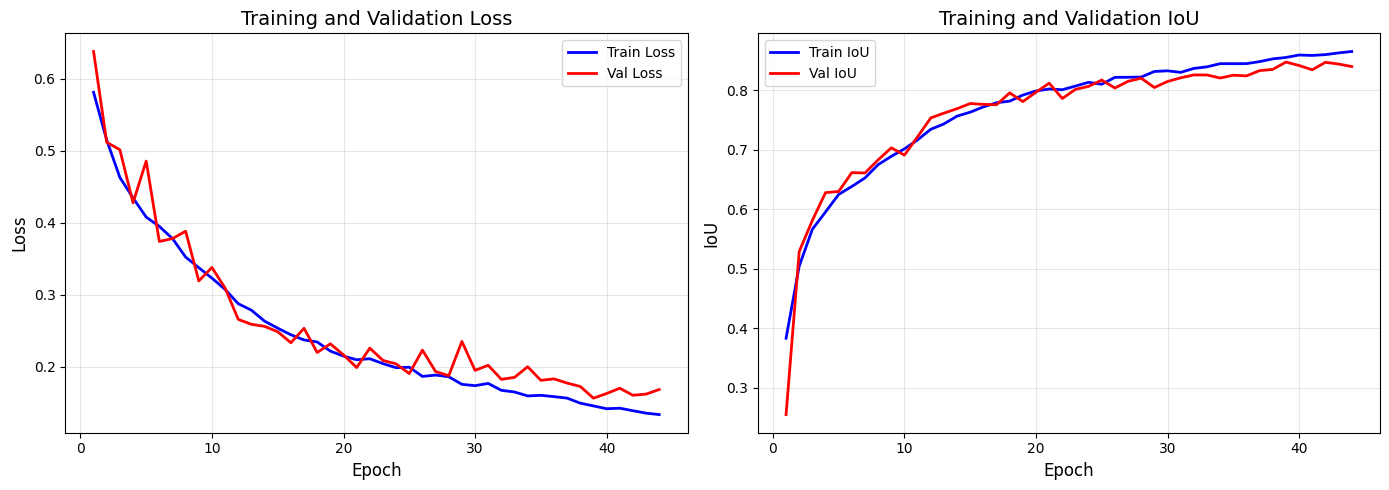

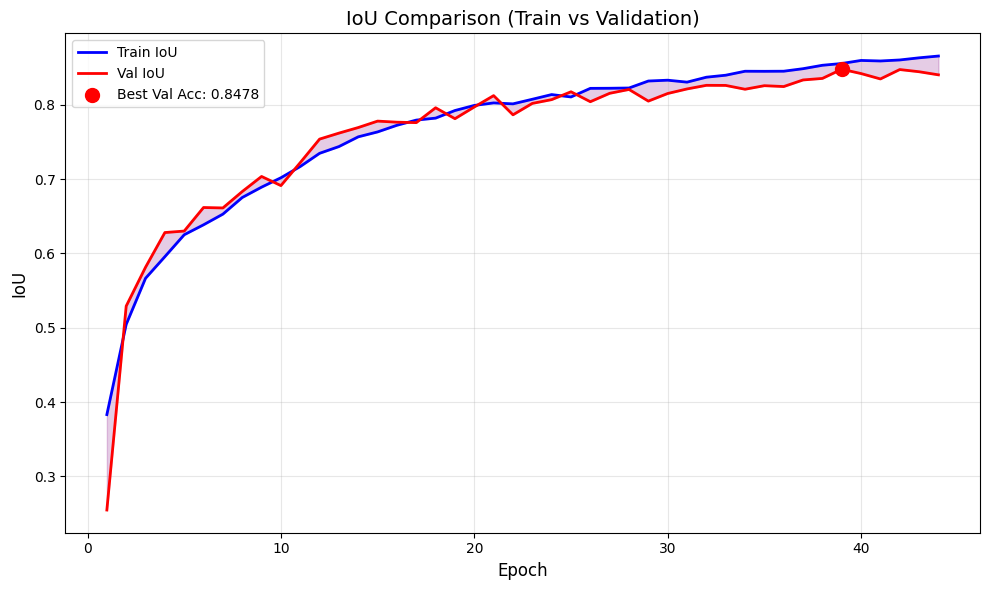

In [ ]:
if os.path.exists('unet_stupid_history.csv'):
    unet_stupid_history = pd.read_csv('unet_stupid_history.csv').to_dict()
plot_metrics(unet_stupid_history)

In [ ]:
# df_history = pd.DataFrame(unet_stupid_history)
# df_history.to_csv('unet_stupid_history.csv', index_label='epoch')

# files.download('best_model_stupid.pt')
# files.download('unet_stupid_history.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# time.sleep(30)

# runtime.unassign()

NameError: name 'time' is not defined

## U-Net

In [ ]:
BATCH_SIZE = 32
LR = 0.001
NUM_EPOCHS = 50
PATIENCE = 5
WEIGHT_DECAY = 1e-4
BEST_MODEL_PATH = 'best_model.pt'
TRAIN_MODEL = False

In [ ]:
# model = UNet(n_channels=3, n_classes=1).to(device)

# if not TRAIN_MODEL:
#     if os.path.exists(BEST_MODEL_PATH):
#         model.load_state_dict(torch.load(BEST_MODEL_PATH))
# else:
#     optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
#     criterion = BCEWithLogitsLoss()
#     scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

#     unet_history = train(
#         model,
#         train_loader_binary,
#         val_loader_binary,
#         criterion,
#         optimizer,
#         scheduler,
#         device=device,
#         num_epochs=NUM_EPOCHS
#     )

In [ ]:
model = UNet(n_channels=3, n_classes=1).to(device)

if os.path.exists('best_model.pt'):
    model.load_state_dict(torch.load('best_model.pt'))


optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = BCEWithLogitsLoss()
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_history = train(
    model,
    train_loader_binary,
    val_loader_binary,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS
)


Epoch 1 / 50
--------------------------------------------------


Train loss: 0.1692, Train IoU: 0.8377, Train Dice: 0.9055
Val loss: 0.2607, Val IoU: 0.7890, Val Dice: 0.8725
Current learning rate: 0.001
Model saved with val loss: 0.2607

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.1637, Train IoU: 0.8421, Train Dice: 0.9088
Val loss: 0.1817, Val IoU: 0.8306, Val Dice: 0.9011
Current learning rate: 0.001
Model saved with val loss: 0.1817

Epoch 3 / 50
--------------------------------------------------


Train loss: 0.1608, Train IoU: 0.8451, Train Dice: 0.9108
Val loss: 0.1816, Val IoU: 0.8358, Val Dice: 0.9044
Current learning rate: 0.001
Model saved with val loss: 0.1816

Epoch 4 / 50
--------------------------------------------------


Train loss: 0.1556, Train IoU: 0.8506, Train Dice: 0.9142
Val loss: 0.1725, Val IoU: 0.8376, Val Dice: 0.9055
Current learning rate: 0.001
Model saved with val loss: 0.1725

Epoch 5 / 50
--------------------------------------------------


...

Train loss: 0.1434, Train IoU: 0.8591, Train Dice: 0.9196
Val loss: 0.1835, Val IoU: 0.8407, Val Dice: 0.9083
Current learning rate: 0.001

Epoch 8 / 50
--------------------------------------------------


Train loss: 0.1410, Train IoU: 0.8611, Train Dice: 0.9210
Val loss: 0.1632, Val IoU: 0.8470, Val Dice: 0.9113
Current learning rate: 0.001

Epoch 9 / 50
--------------------------------------------------


Train loss: 0.1415, Train IoU: 0.8600, Train Dice: 0.9199
Val loss: 0.1674, Val IoU: 0.8481, Val Dice: 0.9130
Current learning rate: 0.001

Epoch 10 / 50
--------------------------------------------------


Train loss: 0.1377, Train IoU: 0.8641, Train Dice: 0.9231
Val loss: 0.1652, Val IoU: 0.8409, Val Dice: 0.9077
Current learning rate: 0.001

Epoch 11 / 50
--------------------------------------------------


Train loss: 0.1349, Train IoU: 0.8663, Train Dice: 0.9242
Val loss: 0.1699, Val IoU: 0.8388, Val Dice: 0.9058
Current learning rate: 0.001
Early stopping


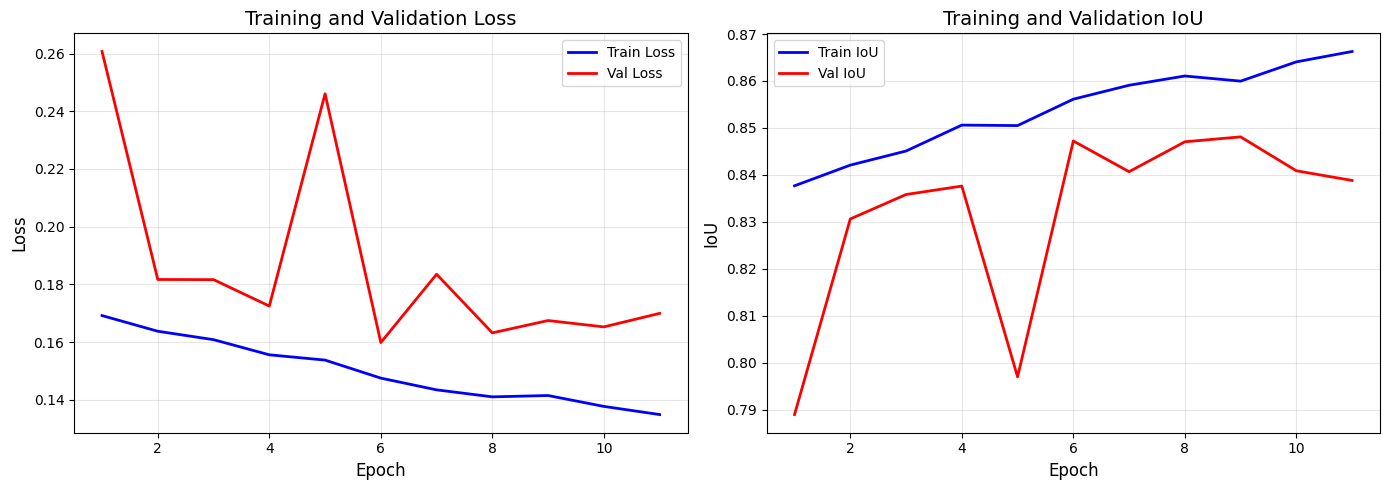

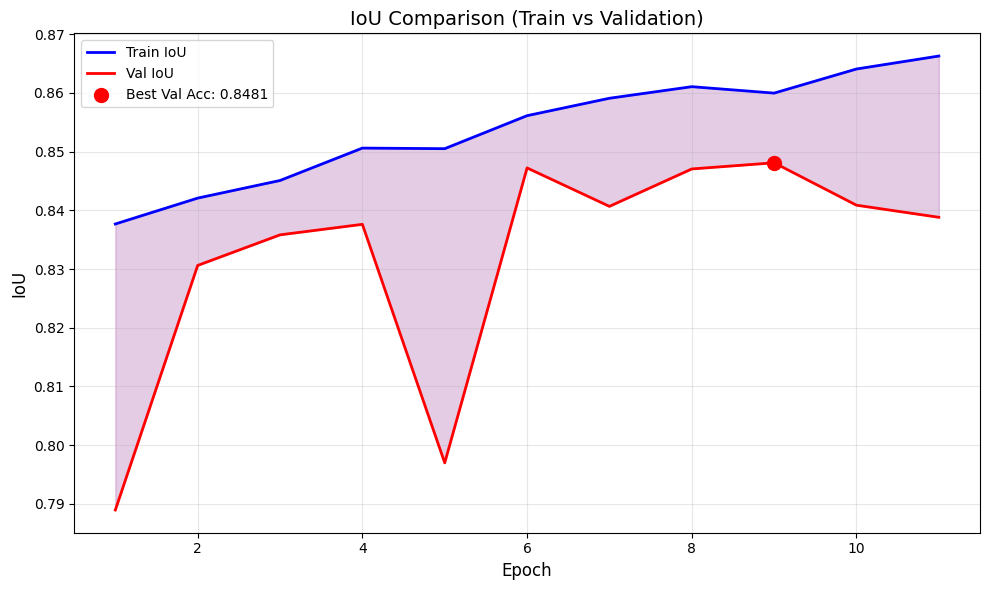

In [ ]:
plot_metrics(unet_history)

In [ ]:
# df_history = pd.DataFrame(unet_history)
# df_history.to_csv('unet_history.csv', index_label='epoch')

# files.download('best_model.pt')
# files.download('unet_history.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# show_result(model, test_dataset)

In [ ]:
# time.sleep(30)

# runtime.unassign()

# Multiclass Segmentation

Что нужно изменить технически для такого эксперимента
1. Изменить Dataset — не объединять trimap в бинарную маску (0=фон, 1=животное+граница), а оставить 3 отдельных класса (или хотя бы 2 явно разделённых: "тело" и "граница", с фоном как третьим)
2. Изменить UNet/StupidUNet — n_classes в OutConv теперь 3, а не 1
3. Изменить loss — переход с BCEWithLogitsLoss на CrossEntropyLoss (multi-class, не multi-label — раз классы взаимоисключающие: каждый пиксель принадлежит ровно одному из трёх классов). Соответственно, маска для CrossEntropyLoss должна быть (B, H, W) с целочисленными классами {0,1,2}, без дополнительной channel-размерности (в отличие от BCE, где было (B, 1, H, W))
4. Изменить compute_metrics — вместо единого бинарного IoU/Dice считать отдельно для каждого класса (обычно это называется mean IoU / per-class IoU) — тебе нужен явный breakdown по классам, а не одно усреднённое число, иначе ты снова "спрячешь" разницу в общем усреднении

## Functions

In [9]:
def compute_metrics_multi(preds, target, threshold=0.5, eps=1e-7):
    # 0 - animal, 1 - background, 2 - boundary
    metrics = {
        'IoU_animal': 0.0,
        'IoU_background': 0.0,
        'IoU_boundary': 0.0,
        'Dice_animal': 0.0,
        'Dice_background': 0.0,
        'Dice_boundary': 0.0,
        'mean_IoU': 0.0,
        'mean_Dice': 0.0
    }

    for i, code in enumerate(('animal', 'background', 'boundary')):
        pred_cls = preds == i
        target_cls = target == i

        intersection = (pred_cls & target_cls).sum()
        union = (pred_cls | target_cls).sum()

        pred_sm = pred_cls.sum()
        target_sm = target_cls.sum()

        iou = (intersection / (union + eps)).item()
        dice = (2 * intersection / (pred_sm + target_sm)).item()

        metrics[f'IoU_{code}'] = iou
        metrics[f'Dice_{code}'] = dice

    mean_iou = sum(metrics[f'IoU_{c}'] for c in ('animal', 'background', 'boundary')) / 3
    mean_dice = sum(metrics[f'Dice_{c}'] for c in ('animal', 'background', 'boundary')) / 3
    metrics['mean_IoU'] = mean_iou
    metrics['mean_Dice'] = mean_dice

    return metrics


def history_append(
    history,
    train_loss,
    train_metrics,
    val_loss,
    val_metrics
):
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    for key in train_metrics.keys():
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])



def train_epoch(
    model,
    data_loader,
    optimizer,
    criterion,
    device,
    compute_metrics_fn,
    multi_class,
    clip_value=1.0,
    threshold=0.5,
    freeze_encoder=False
):
    model.train()
    if freeze_encoder:
        model.encoder.eval()
    total_loss = 0.0
    total_metrics = {}

    for image, mask in tqdm(data_loader, desc='Train', leave=False):
        image = image.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        logits = model(image)
        loss = criterion(logits, mask)
        loss.backward()

        if multi_class:
            preds = (logits.softmax(dim=1).argmax(dim=1)).float()
        else:
            preds = (torch.sigmoid(logits) >= threshold).float()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
        optimizer.step()

        total_loss += loss.item()

        batch_metrics = compute_metrics_fn(preds, mask, threshold=threshold)
        for key, value in batch_metrics.items():
            total_metrics[key] = total_metrics.get(key, 0.0) + value

    avg_loss = total_loss / len(data_loader)
    metrics = {key: value / len(data_loader) for key, value in total_metrics.items()}

    return {
        'loss': avg_loss,
        'metrics': metrics
    }



def evaluate(
    model,
    data_loader,
    criterion,
    device,
    compute_metrics_fn,
    multi_class,
    threshold=0.5
):
    model.eval()
    total_loss = 0.0
    total_metrics = {}

    with torch.no_grad():
        for image, mask in tqdm(data_loader, desc='Val', leave=False):
            image = image.to(device)
            mask = mask.to(device)

            logits = model(image)
            loss = criterion(logits, mask)

            if multi_class:
                preds = (logits.softmax(dim=1).argmax(dim=1)).float()
            else:
                preds = (torch.sigmoid(logits) >= threshold).float()

            total_loss += loss.item()

            batch_metrics = compute_metrics_fn(preds, mask, threshold=threshold)
            for key, value in batch_metrics.items():
                total_metrics[key] = total_metrics.get(key, 0.0) + value

    avg_loss = total_loss / len(data_loader)
    metrics = {key: value / len(data_loader) for key, value in total_metrics.items()}

    return {
        'loss': avg_loss,
        'metrics': metrics
    }


def train(
    model,
    train_loader,
    val_loader,
    criterion, optimizer, scheduler,
    device, num_epochs,
    filename='best_model.pt', compute_metrics_fn=compute_metrics,
    multi_class=False,
    tracking_metric='IoU',
    freeze_encoder=False
):

    history = None
    patience_counter = 0
    best_val_iou = 0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch + 1} / {num_epochs}')
        print('-' * 50)

        result = train_epoch(
            model,
            train_loader, optimizer, criterion, device,
            compute_metrics_fn=compute_metrics_fn, multi_class=multi_class,
            freeze_encoder=freeze_encoder
        )
        train_loss, train_metrics = result['loss'], result['metrics']

        result = evaluate(
            model, val_loader, criterion, device,
            compute_metrics_fn=compute_metrics_fn, multi_class=multi_class
        )
        val_loss, val_metrics = result['loss'], result['metrics']

        scheduler.step(val_loss)

        if history is None:
            history = {'train_loss': [], 'val_loss': []}
            for key in train_metrics:
                history[f'train_{key}'] = []
                history[f'val_{key}'] = []

        history_append(history, train_loss, train_metrics, val_loss, val_metrics)

        train_str = ", ".join(f"{k}: {v:.4f}" for k, v in train_metrics.items())
        val_str = ", ".join(f"{k}: {v:.4f}" for k, v in val_metrics.items())
        print(f"Train loss: {train_loss:.4f}, {train_str}")
        print(f"Val loss: {val_loss:.4f}, {val_str}")
        print(f"Current learning rate: {optimizer.param_groups[0]['lr']}")

        torch.cuda.empty_cache()

        if best_val_iou < val_metrics['mean_IoU']:
            torch.save(model.state_dict(), f'/content/drive/MyDrive/Segmentation project/{filename}.pt')
            best_val_iou = val_metrics['mean_IoU']
            patience_counter = 0
            print(f"Model saved with val mean iou: {best_val_iou:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= 10:
                print('Early stopping')
                break

    return history


In [10]:
def plot_metrics(history):
    if isinstance(history['train_loss'], list):
        train_losses = history['train_loss']
        train_accs = history['train_IoU_animal']
        val_losses = history['val_loss']
        val_accs = history['val_IoU_animal']
    else:
        train_losses = list(history['train_loss'].values())
        train_accs = list(history['train_IoU_animal'].values())
        val_losses = list(history['val_loss'].values())
        val_accs = list(history['val_IoU_animal'].values())

    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График потерь
    ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # График точности
    ax2.plot(epochs, train_accs, 'b-', label='Train IoU', linewidth=2)
    ax2.plot(epochs, val_accs, 'r-', label='Val IoU', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('IoU', fontsize=12)
    ax2.set_title('Training and Validation IoU', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Дополнительный график - сравнение точности
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_accs, 'b-', label='Train IoU', linewidth=2)
    ax.plot(epochs, val_accs, 'r-', label='Val IoU', linewidth=2)
    ax.fill_between(epochs, train_accs, val_accs, alpha=0.2, color='purple')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('IoU', fontsize=12)
    ax.set_title('IoU Comparison (Train vs Validation)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Отмечаем лучшую точность
    best_val_idx = np.argmax(val_accs)
    ax.scatter(best_val_idx + 1, val_accs[best_val_idx],
               color='red', s=100, zorder=5,
               label=f'Best Val Acc: {val_accs[best_val_idx]:.4f}')
    ax.legend()

    plt.tight_layout()
    plt.savefig('iou_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# def get_best_metrics(history, key_metric='IoU'):
#     best_idx = 0
#     best_metric = 0

#     for i in range(len(history[key_metric])):
#         if history[key_metric][i] > best_metric:
#             best_metric = history[key_metric][i]
#             best_idx = i


#     return {
#         'IoU': round(history['val_IoU'][best_idx], 2),
#         'Dice': round(history['val_Dice'][best_idx], 2),
#     }

## Datasets

In [11]:
class OxfordDatasetMulti(Dataset):
    def __init__(self, base_dataset, indecies=None, transform=None):
        self.base_dataset = base_dataset
        self.indecies = indecies if indecies is not None else list(range(len(base_dataset)))

        if transform is None:
            transform = A.Compose([
                A.Resize(256, 256),
                A.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)
                ),
                ToTensorV2()
            ])
        self.transform = transform



    def __len__(self):
        return len(self.indecies)


    def __getitem__(self, idx):
        real_idx = self.indecies[idx]
        image, mask = self.base_dataset[real_idx]

        image = np.array(image)
        mask = np.array(mask)
        mask = mask - 1

        transformed = self.transform(image=image, mask=mask)

        return transformed['image'], transformed['mask'].long()

In [12]:
train_dataset_multi = OxfordDatasetMulti(full_dataset, train_indecies, transform=train_transform)
val_dataset_multi = OxfordDatasetMulti(full_dataset, val_indecies, transform=val_transform)
test_dataset_multi = OxfordDatasetMulti(full_test_dataset)

train_loader_multi = DataLoader(train_dataset_multi, batch_size=32, shuffle=True)
val_loader_multi = DataLoader(val_dataset_multi, batch_size=32, shuffle=False)
test_loader_multi = DataLoader(test_dataset_multi, batch_size=32, shuffle=False)

## Baseline

In [ ]:
BATCH_SIZE = 32
LR = 0.0001
NUM_EPOCHS = 50
PATIENCE = 3
WEIGHT_DECAY = 1e-4
weights = torch.tensor([1.0, 1.0, 3.0])

In [ ]:
model = StupidUNet(n_channels=3, n_classes=3).to(device)

# if os.path.exists('best_model_stupid.pt'):
#     model.load_state_dict(torch.load('best_model_stupid.pt'))

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = CrossEntropyLoss(weight=weights.to(device))
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_stupid_history_multi = train(
    model,
    train_loader_multi,
    val_loader_multi,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    filename='best_model_stupid_multi',
    compute_metrics_fn=compute_metrics_multi,
    multi_class=True
)


Epoch 1 / 50
--------------------------------------------------


Train loss: 0.7745, IoU_animal: 0.4706, IoU_background: 0.6874, IoU_boundary: 0.2177, Dice_animal: 0.6322, Dice_background: 0.8128, Dice_boundary: 0.3502, mean_IoU: 0.4586, mean_Dice: 0.5984
Val loss: 0.6574, IoU_animal: 0.5779, IoU_background: 0.7432, IoU_boundary: 0.3142, Dice_animal: 0.7322, Dice_background: 0.8524, Dice_boundary: 0.4779, mean_IoU: 0.5451, mean_Dice: 0.6875
Current learning rate: 0.0001
Model saved with val loss: 0.5451

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.5659, IoU_animal: 0.6233, IoU_background: 0.7790, IoU_boundary: 0.3445, Dice_animal: 0.7672, Dice_background: 0.8754, Dice_boundary: 0.5118, mean_IoU: 0.5823, mean_Dice: 0.7182
Val loss: 0.5627, IoU_animal: 0.5331, IoU_background: 0.7996, IoU_boundary: 0.3431, Dice_animal: 0.6950, Dice_background: 0.8884, Dice_boundary: 0.5104, mean_IoU: 0.5586, mean_Dice: 0.6979
Current learning rate: 0.0001
Model saved with val loss: 0.5586

Epoch 3 / 50
--------------------------------------------------


Train loss: 0.4958, IoU_animal: 0.6727, IoU_background: 0.8125, IoU_boundary: 0.3833, Dice_animal: 0.8038, Dice_background: 0.8964, Dice_boundary: 0.5538, mean_IoU: 0.6228, mean_Dice: 0.7513
Val loss: 0.4886, IoU_animal: 0.6490, IoU_background: 0.8198, IoU_boundary: 0.3856, Dice_animal: 0.7868, Dice_background: 0.9008, Dice_boundary: 0.5562, mean_IoU: 0.6181, mean_Dice: 0.7479
Current learning rate: 0.0001
Model saved with val loss: 0.6181

Epoch 4 / 50
--------------------------------------------------


Train loss: 0.4539, IoU_animal: 0.6981, IoU_background: 0.8301, IoU_boundary: 0.4088, Dice_animal: 0.8218, Dice_background: 0.9070, Dice_boundary: 0.5800, mean_IoU: 0.6457, mean_Dice: 0.7696
Val loss: 0.4632, IoU_animal: 0.6727, IoU_background: 0.8258, IoU_boundary: 0.3975, Dice_animal: 0.8040, Dice_background: 0.9044, Dice_boundary: 0.5685, mean_IoU: 0.6320, mean_Dice: 0.7590
Current learning rate: 0.0001
Model saved with val loss: 0.6320

Epoch 5 / 50
--------------------------------------------------


...

Train loss: 0.0737, IoU_animal: 0.9576, IoU_background: 0.9784, IoU_boundary: 0.8126, Dice_animal: 0.9783, Dice_background: 0.9891, Dice_boundary: 0.8965, mean_IoU: 0.9162, mean_Dice: 0.9546
Val loss: 0.5597, IoU_animal: 0.7858, IoU_background: 0.8831, IoU_boundary: 0.4710, Dice_animal: 0.8799, Dice_background: 0.9378, Dice_boundary: 0.6401, mean_IoU: 0.7133, mean_Dice: 0.8193
Current learning rate: 6.25e-06

Epoch 25 / 50
--------------------------------------------------


Train loss: 0.0717, IoU_animal: 0.9590, IoU_background: 0.9792, IoU_boundary: 0.8178, Dice_animal: 0.9790, Dice_background: 0.9895, Dice_boundary: 0.8997, mean_IoU: 0.9187, mean_Dice: 0.9561
Val loss: 0.5637, IoU_animal: 0.7845, IoU_background: 0.8830, IoU_boundary: 0.4725, Dice_animal: 0.8791, Dice_background: 0.9378, Dice_boundary: 0.6416, mean_IoU: 0.7134, mean_Dice: 0.8195
Current learning rate: 6.25e-06

Epoch 26 / 50
--------------------------------------------------


Train loss: 0.0699, IoU_animal: 0.9598, IoU_background: 0.9798, IoU_boundary: 0.8215, Dice_animal: 0.9795, Dice_background: 0.9898, Dice_boundary: 0.9019, mean_IoU: 0.9204, mean_Dice: 0.9571
Val loss: 0.5856, IoU_animal: 0.7862, IoU_background: 0.8837, IoU_boundary: 0.4683, Dice_animal: 0.8802, Dice_background: 0.9382, Dice_boundary: 0.6377, mean_IoU: 0.7128, mean_Dice: 0.8187
Current learning rate: 6.25e-06

Epoch 27 / 50
--------------------------------------------------


Train loss: 0.0685, IoU_animal: 0.9610, IoU_background: 0.9803, IoU_boundary: 0.8257, Dice_animal: 0.9801, Dice_background: 0.9901, Dice_boundary: 0.9044, mean_IoU: 0.9224, mean_Dice: 0.9582
Val loss: 0.5846, IoU_animal: 0.7834, IoU_background: 0.8831, IoU_boundary: 0.4695, Dice_animal: 0.8784, Dice_background: 0.9378, Dice_boundary: 0.6388, mean_IoU: 0.7120, mean_Dice: 0.8183
Current learning rate: 3.125e-06

Epoch 28 / 50
--------------------------------------------------


Train loss: 0.0671, IoU_animal: 0.9618, IoU_background: 0.9804, IoU_boundary: 0.8283, Dice_animal: 0.9805, Dice_background: 0.9901, Dice_boundary: 0.9060, mean_IoU: 0.9235, mean_Dice: 0.9589
Val loss: 0.5943, IoU_animal: 0.7840, IoU_background: 0.8824, IoU_boundary: 0.4671, Dice_animal: 0.8788, Dice_background: 0.9374, Dice_boundary: 0.6366, mean_IoU: 0.7112, mean_Dice: 0.8176
Current learning rate: 3.125e-06
Early stopping


In [ ]:
plot_metrics(unet_stupid_history_multi)

AttributeError: 'list' object has no attribute 'values'

In [ ]:
df_history = pd.DataFrame(unet_stupid_history_multi)
df_history.to_csv(f'/content/drive/MyDrive/Segmentation project/unet_stupid_history_multi.csv', index_label='epoch')

# files.download('best_model_stupid_multi.pt')
# files.download('unet_stupid_history_multi.csv')

## U-Net

In [13]:
try:
    del model, optimizer, scheduler, criterion
except:
    pass

torch.cuda.empty_cache()

In [14]:
BATCH_SIZE = 32
LR = 0.0001
NUM_EPOCHS = 50
PATIENCE = 3
WEIGHT_DECAY = 1e-4
weights = torch.tensor([1.0, 1.0, 3.0])

In [15]:
model = UNet(n_channels=3, n_classes=3).to(device)

if os.path.exists('/content/drive/MyDrive/Segmentation project/best_model_multi.pt'):
    model.load_state_dict(torch.load('/content/drive/MyDrive/Segmentation project/best_model_multi.pt'))

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = CrossEntropyLoss(weight=weights.to(device))
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_history_multi = train(
    model,
    train_loader_multi,
    val_loader_multi,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    filename='best_model_multi',
    compute_metrics_fn=compute_metrics_multi,
    multi_class=True
)


Epoch 1 / 50
--------------------------------------------------


Train loss: 0.0864, IoU_animal: 0.9456, IoU_background: 0.9720, IoU_boundary: 0.7734, Dice_animal: 0.9720, Dice_background: 0.9858, Dice_boundary: 0.8720, mean_IoU: 0.8970, mean_Dice: 0.9433
Val loss: 0.5611, IoU_animal: 0.7947, IoU_background: 0.8809, IoU_boundary: 0.4908, Dice_animal: 0.8854, Dice_background: 0.9366, Dice_boundary: 0.6582, mean_IoU: 0.7221, mean_Dice: 0.8267
Current learning rate: 0.0001
Model saved with val mean iou: 0.7221

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.0811, IoU_animal: 0.9489, IoU_background: 0.9736, IoU_boundary: 0.7818, Dice_animal: 0.9738, Dice_background: 0.9866, Dice_boundary: 0.8774, mean_IoU: 0.9015, mean_Dice: 0.9459
Val loss: 0.6604, IoU_animal: 0.7773, IoU_background: 0.8723, IoU_boundary: 0.4568, Dice_animal: 0.8745, Dice_background: 0.9317, Dice_boundary: 0.6270, mean_IoU: 0.7021, mean_Dice: 0.8110
Current learning rate: 0.0001

Epoch 3 / 50
--------------------------------------------------


Train loss: 0.0932, IoU_animal: 0.9406, IoU_background: 0.9691, IoU_boundary: 0.7606, Dice_animal: 0.9694, Dice_background: 0.9843, Dice_boundary: 0.8639, mean_IoU: 0.8901, mean_Dice: 0.9392
Val loss: 0.5770, IoU_animal: 0.7704, IoU_background: 0.8827, IoU_boundary: 0.4839, Dice_animal: 0.8703, Dice_background: 0.9376, Dice_boundary: 0.6519, mean_IoU: 0.7123, mean_Dice: 0.8199
Current learning rate: 0.0001

Epoch 4 / 50
--------------------------------------------------


Train loss: 0.0883, IoU_animal: 0.9437, IoU_background: 0.9709, IoU_boundary: 0.7689, Dice_animal: 0.9710, Dice_background: 0.9852, Dice_boundary: 0.8692, mean_IoU: 0.8945, mean_Dice: 0.9418
Val loss: 0.5903, IoU_animal: 0.7848, IoU_background: 0.8807, IoU_boundary: 0.4836, Dice_animal: 0.8793, Dice_background: 0.9365, Dice_boundary: 0.6517, mean_IoU: 0.7164, mean_Dice: 0.8225
Current learning rate: 0.0001

Epoch 5 / 50
--------------------------------------------------


...

Train loss: 0.0414, IoU_animal: 0.9738, IoU_background: 0.9867, IoU_boundary: 0.8772, Dice_animal: 0.9867, Dice_background: 0.9933, Dice_boundary: 0.9345, mean_IoU: 0.9459, mean_Dice: 0.9715
Val loss: 0.7451, IoU_animal: 0.8078, IoU_background: 0.8944, IoU_boundary: 0.4992, Dice_animal: 0.8936, Dice_background: 0.9442, Dice_boundary: 0.6657, mean_IoU: 0.7338, mean_Dice: 0.8345
Current learning rate: 1.25e-05

Epoch 14 / 50
--------------------------------------------------


Train loss: 0.0393, IoU_animal: 0.9752, IoU_background: 0.9875, IoU_boundary: 0.8834, Dice_animal: 0.9875, Dice_background: 0.9937, Dice_boundary: 0.9380, mean_IoU: 0.9487, mean_Dice: 0.9731
Val loss: 0.7594, IoU_animal: 0.8064, IoU_background: 0.8938, IoU_boundary: 0.4986, Dice_animal: 0.8928, Dice_background: 0.9439, Dice_boundary: 0.6651, mean_IoU: 0.7329, mean_Dice: 0.8339
Current learning rate: 1.25e-05

Epoch 15 / 50
--------------------------------------------------


Train loss: 0.0378, IoU_animal: 0.9763, IoU_background: 0.9880, IoU_boundary: 0.8880, Dice_animal: 0.9880, Dice_background: 0.9940, Dice_boundary: 0.9406, mean_IoU: 0.9508, mean_Dice: 0.9742
Val loss: 0.7844, IoU_animal: 0.8082, IoU_background: 0.8956, IoU_boundary: 0.4933, Dice_animal: 0.8938, Dice_background: 0.9448, Dice_boundary: 0.6604, mean_IoU: 0.7324, mean_Dice: 0.8330
Current learning rate: 1.25e-05

Epoch 16 / 50
--------------------------------------------------


Train loss: 0.0381, IoU_animal: 0.9760, IoU_background: 0.9879, IoU_boundary: 0.8866, Dice_animal: 0.9878, Dice_background: 0.9939, Dice_boundary: 0.9398, mean_IoU: 0.9502, mean_Dice: 0.9739
Val loss: 0.7653, IoU_animal: 0.8066, IoU_background: 0.8948, IoU_boundary: 0.4985, Dice_animal: 0.8928, Dice_background: 0.9444, Dice_boundary: 0.6651, mean_IoU: 0.7333, mean_Dice: 0.8341
Current learning rate: 1.25e-05

Epoch 17 / 50
--------------------------------------------------


Train loss: 0.0369, IoU_animal: 0.9769, IoU_background: 0.9883, IoU_boundary: 0.8907, Dice_animal: 0.9883, Dice_background: 0.9941, Dice_boundary: 0.9421, mean_IoU: 0.9520, mean_Dice: 0.9749
Val loss: 0.7555, IoU_animal: 0.8054, IoU_background: 0.8933, IoU_boundary: 0.5025, Dice_animal: 0.8921, Dice_background: 0.9436, Dice_boundary: 0.6687, mean_IoU: 0.7337, mean_Dice: 0.8348
Current learning rate: 6.25e-06
Early stopping


In [16]:
# Epoch 1 / 50
# --------------------------------------------------
# Train loss: 0.1420, IoU_animal: 0.9105, IoU_background: 0.9545, IoU_boundary: 0.6720, Dice_animal: 0.9531, Dice_background: 0.9767, Dice_boundary: 0.8036, mean_IoU: 0.8457, mean_Dice: 0.9111
# Val loss: 0.5086, IoU_animal: 0.7666, IoU_background: 0.8783, IoU_boundary: 0.4791, Dice_animal: 0.8678, Dice_background: 0.9351, Dice_boundary: 0.6476, mean_IoU: 0.7080, mean_Dice: 0.8168
# Current learning rate: 0.0001
# Model saved with val mean iou: 0.7080

# Epoch 2 / 50
# --------------------------------------------------
# Train loss: 0.1384, IoU_animal: 0.9113, IoU_background: 0.9554, IoU_boundary: 0.6783, Dice_animal: 0.9535, Dice_background: 0.9772, Dice_boundary: 0.8081, mean_IoU: 0.8483, mean_Dice: 0.9129
# Val loss: 0.4766, IoU_animal: 0.7844, IoU_background: 0.8743, IoU_boundary: 0.4780, Dice_animal: 0.8790, Dice_background: 0.9328, Dice_boundary: 0.6466, mean_IoU: 0.7122, mean_Dice: 0.8195
# Current learning rate: 0.0001
# Model saved with val mean iou: 0.7122

# Epoch 3 / 50
# --------------------------------------------------
# Train loss: 0.1322, IoU_animal: 0.9158, IoU_background: 0.9576, IoU_boundary: 0.6851, Dice_animal: 0.9560, Dice_background: 0.9784, Dice_boundary: 0.8129, mean_IoU: 0.8528, mean_Dice: 0.9158
# Val loss: 0.5279, IoU_animal: 0.7582, IoU_background: 0.8774, IoU_boundary: 0.4786, Dice_animal: 0.8623, Dice_background: 0.9346, Dice_boundary: 0.6470, mean_IoU: 0.7047, mean_Dice: 0.8147
# Current learning rate: 0.0001

# Epoch 4 / 50
# --------------------------------------------------
# Train loss: 0.1275, IoU_animal: 0.9182, IoU_background: 0.9586, IoU_boundary: 0.6926, Dice_animal: 0.9573, Dice_background: 0.9789, Dice_boundary: 0.8182, mean_IoU: 0.8565, mean_Dice: 0.9181
# Val loss: 0.4714, IoU_animal: 0.7688, IoU_background: 0.8798, IoU_boundary: 0.4812, Dice_animal: 0.8692, Dice_background: 0.9360, Dice_boundary: 0.6495, mean_IoU: 0.7099, mean_Dice: 0.8182
# Current learning rate: 0.0001

# Epoch 5 / 50
# --------------------------------------------------
# Train loss: 0.1229, IoU_animal: 0.9213, IoU_background: 0.9605, IoU_boundary: 0.7012, Dice_animal: 0.9590, Dice_background: 0.9799, Dice_boundary: 0.8242, mean_IoU: 0.8610, mean_Dice: 0.9210
# Val loss: 0.4705, IoU_animal: 0.7734, IoU_background: 0.8787, IoU_boundary: 0.4822, Dice_animal: 0.8721, Dice_background: 0.9353, Dice_boundary: 0.6505, mean_IoU: 0.7115, mean_Dice: 0.8193
# Current learning rate: 0.0001

# Epoch 6 / 50
# --------------------------------------------------
# Train loss: 0.1172, IoU_animal: 0.9244, IoU_background: 0.9624, IoU_boundary: 0.7094, Dice_animal: 0.9607, Dice_background: 0.9808, Dice_boundary: 0.8298, mean_IoU: 0.8654, mean_Dice: 0.9238
# Val loss: 0.4875, IoU_animal: 0.7516, IoU_background: 0.8744, IoU_boundary: 0.4670, Dice_animal: 0.8580, Dice_background: 0.9329, Dice_boundary: 0.6365, mean_IoU: 0.6977, mean_Dice: 0.8091
# Current learning rate: 0.0001

# Epoch 7 / 50
# --------------------------------------------------
# Train loss: 0.1155, IoU_animal: 0.9247, IoU_background: 0.9623, IoU_boundary: 0.7144, Dice_animal: 0.9609, Dice_background: 0.9808, Dice_boundary: 0.8332, mean_IoU: 0.8672, mean_Dice: 0.9250
# Val loss: 0.5295, IoU_animal: 0.7953, IoU_background: 0.8856, IoU_boundary: 0.4895, Dice_animal: 0.8859, Dice_background: 0.9393, Dice_boundary: 0.6571, mean_IoU: 0.7235, mean_Dice: 0.8274
# Current learning rate: 0.0001
# Model saved with val mean iou: 0.7235

# Epoch 8 / 50
# --------------------------------------------------
# Train loss: 0.1043, IoU_animal: 0.9334, IoU_background: 0.9662, IoU_boundary: 0.7327, Dice_animal: 0.9656, Dice_background: 0.9828, Dice_boundary: 0.8456, mean_IoU: 0.8774, mean_Dice: 0.9313
# Val loss: 0.5776, IoU_animal: 0.7393, IoU_background: 0.8775, IoU_boundary: 0.4661, Dice_animal: 0.8500, Dice_background: 0.9347, Dice_boundary: 0.6356, mean_IoU: 0.6943, mean_Dice: 0.8068
# Current learning rate: 0.0001

# Epoch 9 / 50
# --------------------------------------------------
# Train loss: 0.1040, IoU_animal: 0.9331, IoU_background: 0.9663, IoU_boundary: 0.7353, Dice_animal: 0.9654, Dice_background: 0.9829, Dice_boundary: 0.8473, mean_IoU: 0.8782, mean_Dice: 0.9319
# Val loss: 0.5205, IoU_animal: 0.7831, IoU_background: 0.8802, IoU_boundary: 0.4869, Dice_animal: 0.8782, Dice_background: 0.9362, Dice_boundary: 0.6547, mean_IoU: 0.7167, mean_Dice: 0.8230
# Current learning rate: 5e-05

# Epoch 10 / 50
# --------------------------------------------------
# Train loss: 0.0870, IoU_animal: 0.9452, IoU_background: 0.9715, IoU_boundary: 0.7667, Dice_animal: 0.9718, Dice_background: 0.9855, Dice_boundary: 0.8678, mean_IoU: 0.8944, mean_Dice: 0.9417
# Val loss: 0.5230, IoU_animal: 0.8005, IoU_background: 0.8927, IoU_boundary: 0.5059, Dice_animal: 0.8891, Dice_background: 0.9432, Dice_boundary: 0.6717, mean_IoU: 0.7330, mean_Dice: 0.8346
# Current learning rate: 5e-05
# Model saved with val mean iou: 0.7330

# Epoch 11 / 50
# --------------------------------------------------
# Train loss: 0.0770, IoU_animal: 0.9517, IoU_background: 0.9750, IoU_boundary: 0.7894, Dice_animal: 0.9753, Dice_background: 0.9873, Dice_boundary: 0.8822, mean_IoU: 0.9054, mean_Dice: 0.9483
# Val loss: 0.5489, IoU_animal: 0.7979, IoU_background: 0.8893, IoU_boundary: 0.5032, Dice_animal: 0.8875, Dice_background: 0.9413, Dice_boundary: 0.6693, mean_IoU: 0.7301, mean_Dice: 0.8327
# Current learning rate: 5e-05

# Epoch 12 / 50
# --------------------------------------------------
# Train loss: 0.0723, IoU_animal: 0.9546, IoU_background: 0.9765, IoU_boundary: 0.8003, Dice_animal: 0.9768, Dice_background: 0.9881, Dice_boundary: 0.8889, mean_IoU: 0.9105, mean_Dice: 0.9513
# Val loss: 0.5763, IoU_animal: 0.8034, IoU_background: 0.8936, IoU_boundary: 0.5053, Dice_animal: 0.8909, Dice_background: 0.9437, Dice_boundary: 0.6711, mean_IoU: 0.7341, mean_Dice: 0.8352
# Current learning rate: 5e-05
# Model saved with val mean iou: 0.7341

# Epoch 13 / 50
# --------------------------------------------------
# Train loss: 0.0686, IoU_animal: 0.9568, IoU_background: 0.9776, IoU_boundary: 0.8086, Dice_animal: 0.9779, Dice_background: 0.9887, Dice_boundary: 0.8941, mean_IoU: 0.9143, mean_Dice: 0.9536
# Val loss: 0.6027, IoU_animal: 0.8047, IoU_background: 0.8929, IoU_boundary: 0.5015, Dice_animal: 0.8916, Dice_background: 0.9433, Dice_boundary: 0.6678, mean_IoU: 0.7330, mean_Dice: 0.8343
# Current learning rate: 2.5e-05

# Epoch 14 / 50
# --------------------------------------------------
# Train loss: 0.0630, IoU_animal: 0.9605, IoU_background: 0.9796, IoU_boundary: 0.8229, Dice_animal: 0.9799, Dice_background: 0.9897, Dice_boundary: 0.9027, mean_IoU: 0.9210, mean_Dice: 0.9574
# Val loss: 0.6138, IoU_animal: 0.8035, IoU_background: 0.8935, IoU_boundary: 0.5024, Dice_animal: 0.8909, Dice_background: 0.9436, Dice_boundary: 0.6685, mean_IoU: 0.7331, mean_Dice: 0.8344
# Current learning rate: 2.5e-05

# Epoch 15 / 50
# --------------------------------------------------
# Train loss: 0.0591, IoU_animal: 0.9632, IoU_background: 0.9810, IoU_boundary: 0.8331, Dice_animal: 0.9813, Dice_background: 0.9904, Dice_boundary: 0.9089, mean_IoU: 0.9258, mean_Dice: 0.9602
# Val loss: 0.6333, IoU_animal: 0.8069, IoU_background: 0.8949, IoU_boundary: 0.5024, Dice_animal: 0.8931, Dice_background: 0.9445, Dice_boundary: 0.6686, mean_IoU: 0.7348, mean_Dice: 0.8354
# Current learning rate: 2.5e-05
# Model saved with val mean iou: 0.7348

# Epoch 16 / 50
# --------------------------------------------------
# Train loss: 0.0580, IoU_animal: 0.9637, IoU_background: 0.9813, IoU_boundary: 0.8350, Dice_animal: 0.9815, Dice_background: 0.9905, Dice_boundary: 0.9100, mean_IoU: 0.9267, mean_Dice: 0.9607
# Val loss: 0.6733, IoU_animal: 0.8075, IoU_background: 0.8955, IoU_boundary: 0.4915, Dice_animal: 0.8934, Dice_background: 0.9448, Dice_boundary: 0.6589, mean_IoU: 0.7315, mean_Dice: 0.8324
# Current learning rate: 2.5e-05

# Epoch 17 / 50
# --------------------------------------------------
# Train loss: 0.0555, IoU_animal: 0.9654, IoU_background: 0.9822, IoU_boundary: 0.8419, Dice_animal: 0.9824, Dice_background: 0.9910, Dice_boundary: 0.9141, mean_IoU: 0.9298, mean_Dice: 0.9625
# Val loss: 0.6483, IoU_animal: 0.8014, IoU_background: 0.8921, IoU_boundary: 0.5009, Dice_animal: 0.8897, Dice_background: 0.9429, Dice_boundary: 0.6672, mean_IoU: 0.7314, mean_Dice: 0.8332
# Current learning rate: 1.25e-05

# Epoch 18 / 50
# --------------------------------------------------
# Train loss: 0.0532, IoU_animal: 0.9667, IoU_background: 0.9828, IoU_boundary: 0.8469, Dice_animal: 0.9830, Dice_background: 0.9913, Dice_boundary: 0.9170, mean_IoU: 0.9321, mean_Dice: 0.9638
# Val loss: 0.6744, IoU_animal: 0.8059, IoU_background: 0.8947, IoU_boundary: 0.4965, Dice_animal: 0.8924, Dice_background: 0.9443, Dice_boundary: 0.6633, mean_IoU: 0.7323, mean_Dice: 0.8334
# Current learning rate: 1.25e-05

# Epoch 19 / 50
# --------------------------------------------------
# Train loss: 0.0510, IoU_animal: 0.9686, IoU_background: 0.9836, IoU_boundary: 0.8539, Dice_animal: 0.9840, Dice_background: 0.9917, Dice_boundary: 0.9211, mean_IoU: 0.9354, mean_Dice: 0.9656
# Val loss: 0.6862, IoU_animal: 0.8072, IoU_background: 0.8938, IoU_boundary: 0.4957, Dice_animal: 0.8932, Dice_background: 0.9439, Dice_boundary: 0.6626, mean_IoU: 0.7322, mean_Dice: 0.8332
# Current learning rate: 1.25e-05

# Epoch 20 / 50
# --------------------------------------------------
# Train loss: 0.0501, IoU_animal: 0.9688, IoU_background: 0.9838, IoU_boundary: 0.8553, Dice_animal: 0.9842, Dice_background: 0.9919, Dice_boundary: 0.9219, mean_IoU: 0.9360, mean_Dice: 0.9660
# Val loss: 0.6753, IoU_animal: 0.8026, IoU_background: 0.8927, IoU_boundary: 0.4991, Dice_animal: 0.8904, Dice_background: 0.9432, Dice_boundary: 0.6656, mean_IoU: 0.7314, mean_Dice: 0.8331
# Current learning rate: 1.25e-05

# Epoch 21 / 50
# --------------------------------------------------
# Train loss: 0.0492, IoU_animal: 0.9696, IoU_background: 0.9842, IoU_boundary: 0.8583, Dice_animal: 0.9846, Dice_background: 0.9920, Dice_boundary: 0.9236, mean_IoU: 0.9374, mean_Dice: 0.9668
# Val loss: 0.6912, IoU_animal: 0.8050, IoU_background: 0.8925, IoU_boundary: 0.4984, Dice_animal: 0.8919, Dice_background: 0.9431, Dice_boundary: 0.6650, mean_IoU: 0.7320, mean_Dice: 0.8333
# Current learning rate: 6.25e-06

# Epoch 22 / 50
# --------------------------------------------------
# Train loss: 0.0481, IoU_animal: 0.9703, IoU_background: 0.9846, IoU_boundary: 0.8611, Dice_animal: 0.9849, Dice_background: 0.9923, Dice_boundary: 0.9253, mean_IoU: 0.9387, mean_Dice: 0.9675
# Val loss: 0.7009, IoU_animal: 0.8048, IoU_background: 0.8934, IoU_boundary: 0.4957, Dice_animal: 0.8917, Dice_background: 0.9436, Dice_boundary: 0.6626, mean_IoU: 0.7313, mean_Dice: 0.8327
# Current learning rate: 6.25e-06

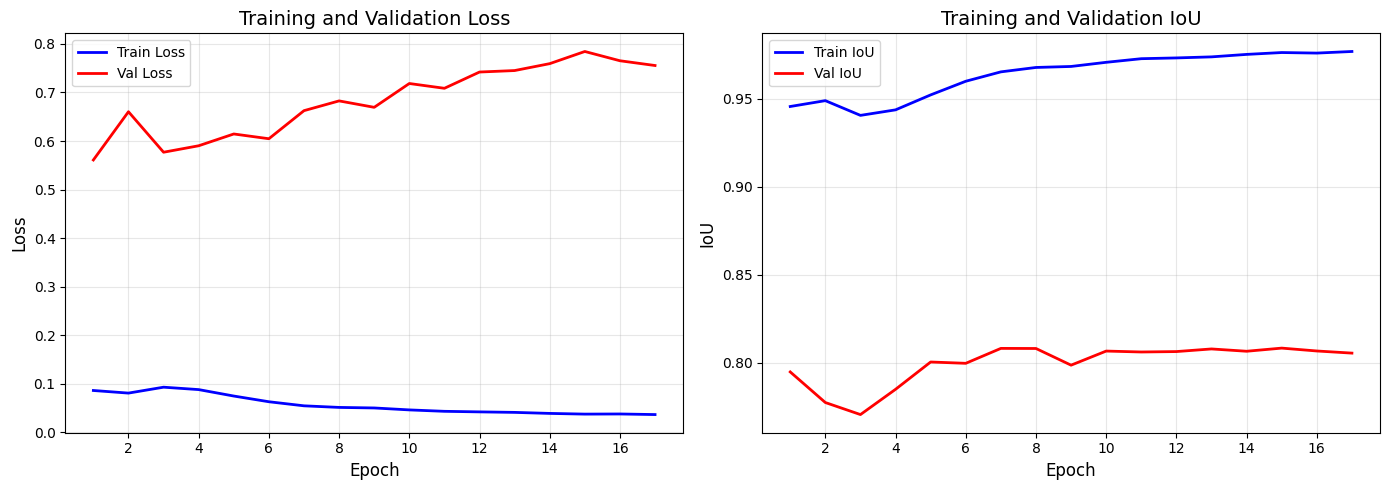

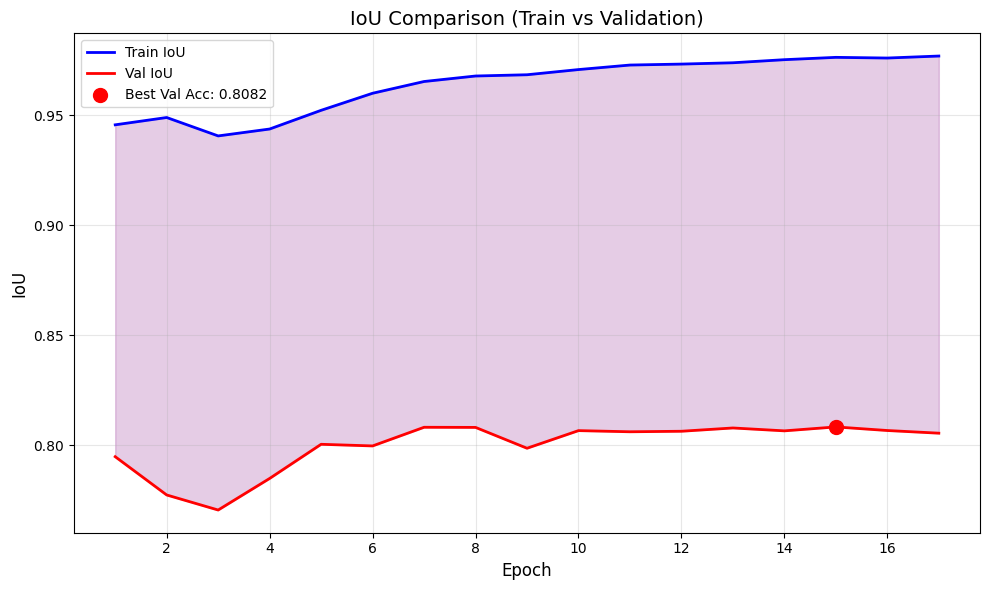

In [17]:
plot_metrics(unet_history_multi)

In [18]:
df_history = pd.DataFrame(unet_history_multi)
df_history.to_csv(f'/content/drive/MyDrive/Segmentation project/unet_history_multi.csv', index_label='epoch')

# files.download('best_model_multi.pt')
# files.download('unet_history_multi.csv')

## ResNet transfer learning

In [19]:
try:
    del model, optimizer, scheduler, criterion
except:
    pass

torch.cuda.empty_cache()

In [16]:
class ResNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet34(weights=ResNet34_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu
        )
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

    def forward(self, x):
        x1 = self.stem(x)                     # 64, 128, 128
        x2 = self.layer1(self.maxpool(x1))    # 64, 64, 64
        x3 = self.layer2(x2)                  # 128, 32, 32
        x4 = self.layer3(x3)                  # 256, 16, 16
        x5 = self.layer4(x4)                  # 512, 8, 8

        return x1, x2, x3, x4, x5


class UNetResNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()
        self.encoder = ResNetEncoder()

        self.up1 = UpSample(512, 256, skip_ch=256)
        self.up2 = UpSample(256, 128, skip_ch=128)
        self.up3 = UpSample(128, 64, skip_ch=64)
        self.up4 = UpSample(64, 64, skip_ch=64)
        self.up5 = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2),
            DoubleConv(64, 64)
        )
        self.out = OutConv(64, n_classes)

    def forward(self, x):
        x1, x2, x3, x4, x5 = self.encoder(x)
        x = self.up1(x5, x4)     # x = (256, ..., ...)
        x = self.up2(x, x3)      # x = (128, ..., ...)
        x = self.up3(x, x2)      # x = (64, ..., ...)
        x = self.up4(x, x1)      # x = (64, 128, 128)
        x = self.up5(x)

        logits = self.out(x)

        return logits

In [21]:
def freeze_weights(model):
    for param in model.encoder.parameters():
        param.requires_grad = False


def unfreeze_weights(model):
    for param in model.encoder.parameters():
        param.requires_grad = True
    model.encoder.train()

In [22]:
BATCH_SIZE = 32
LR = 0.0001
NUM_EPOCHS = 50
PATIENCE = 3
WEIGHT_DECAY = 1e-4
weights = torch.tensor([1.0, 1.0, 3.0])

In [23]:
model = UNetResNet(n_channels=3, n_classes=3).to(device)
freeze_weights(model)

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY)

criterion = CrossEntropyLoss(weight=weights.to(device))
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_history_multi_transfer_frozen = train(
    model,
    train_loader_multi,
    val_loader_multi,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    filename='best_model_multi_transfer',
    compute_metrics_fn=compute_metrics_multi,
    multi_class=True,
    freeze_encoder=True
)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 115MB/s]



Epoch 1 / 50
--------------------------------------------------


Train loss: 0.5436, IoU_animal: 0.7292, IoU_background: 0.8267, IoU_boundary: 0.3810, Dice_animal: 0.8297, Dice_background: 0.8948, Dice_boundary: 0.5381, mean_IoU: 0.6456, mean_Dice: 0.7542
Val loss: 0.3961, IoU_animal: 0.7208, IoU_background: 0.8915, IoU_boundary: 0.4282, Dice_animal: 0.8376, Dice_background: 0.9426, Dice_boundary: 0.5995, mean_IoU: 0.6802, mean_Dice: 0.7932
Current learning rate: 0.0001
Model saved with val mean iou: 0.6802

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.3311, IoU_animal: 0.8388, IoU_background: 0.9103, IoU_boundary: 0.5146, Dice_animal: 0.9122, Dice_background: 0.9530, Dice_boundary: 0.6792, mean_IoU: 0.7545, mean_Dice: 0.8481
Val loss: 0.3157, IoU_animal: 0.8559, IoU_background: 0.8953, IoU_boundary: 0.5015, Dice_animal: 0.9223, Dice_background: 0.9447, Dice_boundary: 0.6678, mean_IoU: 0.7509, mean_Dice: 0.8449
Current learning rate: 0.0001
Model saved with val mean iou: 0.7509

Epoch 3 / 50
--------------------------------------------------


...

Train loss: 0.0930, IoU_animal: 0.9462, IoU_background: 0.9730, IoU_boundary: 0.7719, Dice_animal: 0.9724, Dice_background: 0.9863, Dice_boundary: 0.8711, mean_IoU: 0.8970, mean_Dice: 0.9433
Val loss: 0.3322, IoU_animal: 0.8654, IoU_background: 0.9309, IoU_boundary: 0.5578, Dice_animal: 0.9278, Dice_background: 0.9642, Dice_boundary: 0.7160, mean_IoU: 0.7847, mean_Dice: 0.8693
Current learning rate: 2.5e-05

Epoch 18 / 50
--------------------------------------------------


Train loss: 0.0909, IoU_animal: 0.9472, IoU_background: 0.9732, IoU_boundary: 0.7751, Dice_animal: 0.9729, Dice_background: 0.9864, Dice_boundary: 0.8732, mean_IoU: 0.8985, mean_Dice: 0.9442
Val loss: 0.3444, IoU_animal: 0.8689, IoU_background: 0.9305, IoU_boundary: 0.5564, Dice_animal: 0.9298, Dice_background: 0.9640, Dice_boundary: 0.7148, mean_IoU: 0.7852, mean_Dice: 0.8695
Current learning rate: 2.5e-05

Epoch 19 / 50
--------------------------------------------------


Train loss: 0.0890, IoU_animal: 0.9486, IoU_background: 0.9736, IoU_boundary: 0.7786, Dice_animal: 0.9736, Dice_background: 0.9866, Dice_boundary: 0.8754, mean_IoU: 0.9003, mean_Dice: 0.9452
Val loss: 0.3522, IoU_animal: 0.8660, IoU_background: 0.9303, IoU_boundary: 0.5559, Dice_animal: 0.9281, Dice_background: 0.9639, Dice_boundary: 0.7145, mean_IoU: 0.7841, mean_Dice: 0.8688
Current learning rate: 1.25e-05

Epoch 20 / 50
--------------------------------------------------


Train loss: 0.0850, IoU_animal: 0.9513, IoU_background: 0.9752, IoU_boundary: 0.7886, Dice_animal: 0.9750, Dice_background: 0.9874, Dice_boundary: 0.8817, mean_IoU: 0.9050, mean_Dice: 0.9481
Val loss: 0.3568, IoU_animal: 0.8672, IoU_background: 0.9295, IoU_boundary: 0.5541, Dice_animal: 0.9288, Dice_background: 0.9634, Dice_boundary: 0.7130, mean_IoU: 0.7836, mean_Dice: 0.8684
Current learning rate: 1.25e-05

Epoch 21 / 50
--------------------------------------------------


Train loss: 0.0836, IoU_animal: 0.9522, IoU_background: 0.9756, IoU_boundary: 0.7920, Dice_animal: 0.9755, Dice_background: 0.9877, Dice_boundary: 0.8838, mean_IoU: 0.9066, mean_Dice: 0.9490
Val loss: 0.3606, IoU_animal: 0.8663, IoU_background: 0.9314, IoU_boundary: 0.5540, Dice_animal: 0.9283, Dice_background: 0.9644, Dice_boundary: 0.7129, mean_IoU: 0.7839, mean_Dice: 0.8685
Current learning rate: 1.25e-05
Early stopping


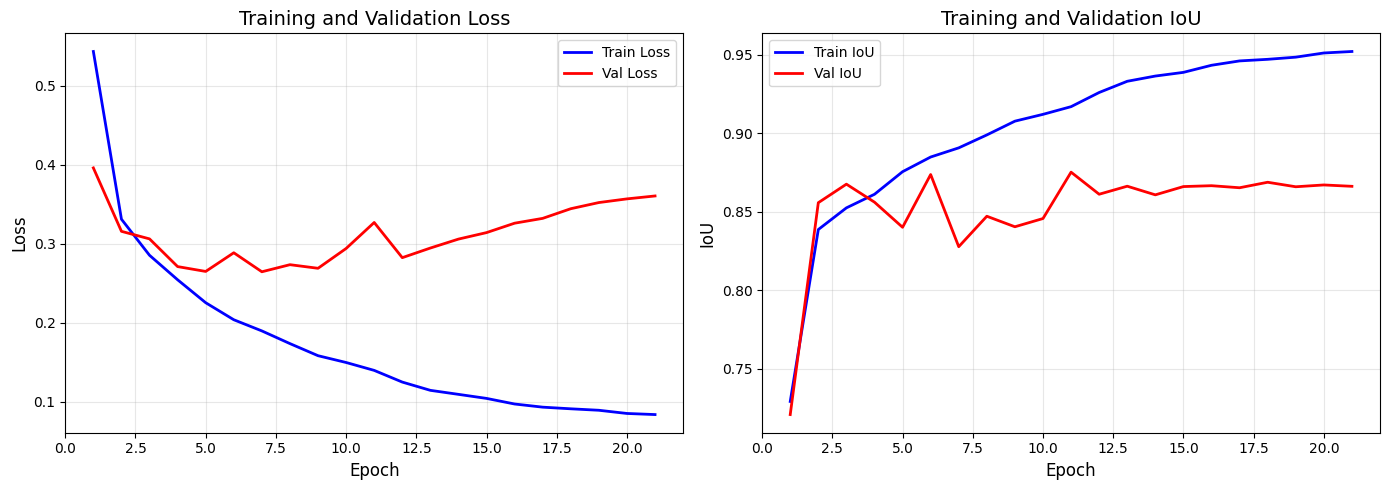

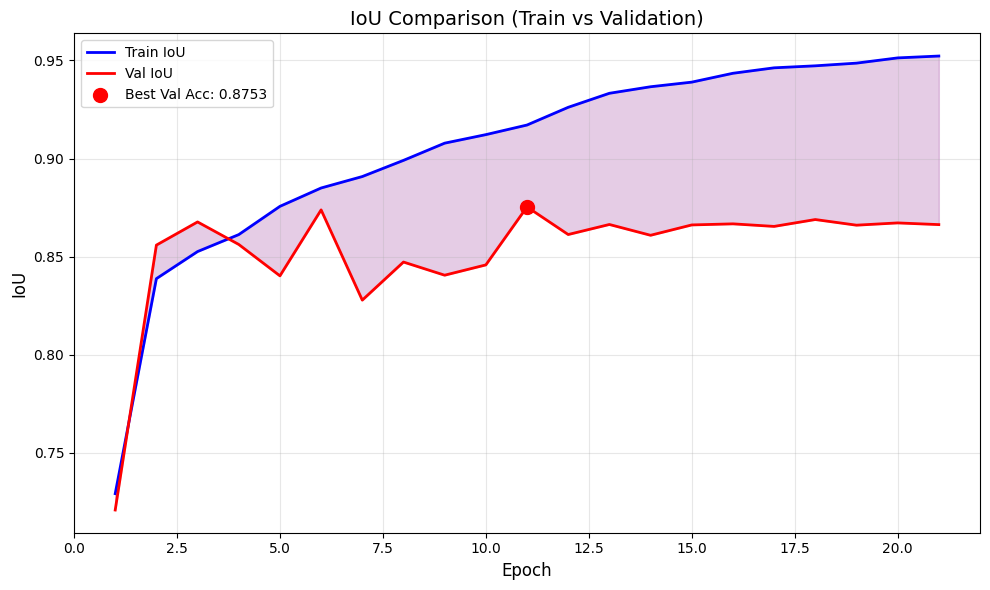

In [24]:
plot_metrics(unet_history_multi_transfer_frozen)

In [25]:
df_history = pd.DataFrame(unet_history_multi_transfer_frozen)
df_history.to_csv(f'/content/drive/MyDrive/Segmentation project/unet_history_multi_transfer_frozen.csv', index_label='epoch')

In [26]:
unfreeze_weights(model)
del optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LR, weight_decay=WEIGHT_DECAY)

criterion = CrossEntropyLoss(weight=weights.to(device))
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=PATIENCE)

unet_history_multi_transfer_unfrozen = train(
    model,
    train_loader_multi,
    val_loader_multi,
    criterion,
    optimizer,
    scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    filename='best_model_multi_transfer_unfrozen',
    compute_metrics_fn=compute_metrics_multi,
    multi_class=True,
    freeze_encoder=False
)


Epoch 1 / 50
--------------------------------------------------


Train loss: 0.1748, IoU_animal: 0.8934, IoU_background: 0.9452, IoU_boundary: 0.6411, Dice_animal: 0.9437, Dice_background: 0.9718, Dice_boundary: 0.7811, mean_IoU: 0.8266, mean_Dice: 0.8989
Val loss: 0.2810, IoU_animal: 0.8551, IoU_background: 0.9261, IoU_boundary: 0.5516, Dice_animal: 0.9218, Dice_background: 0.9616, Dice_boundary: 0.7108, mean_IoU: 0.7776, mean_Dice: 0.8647
Current learning rate: 0.0001
Model saved with val mean iou: 0.7776

Epoch 2 / 50
--------------------------------------------------


Train loss: 0.1529, IoU_animal: 0.9047, IoU_background: 0.9518, IoU_boundary: 0.6605, Dice_animal: 0.9499, Dice_background: 0.9753, Dice_boundary: 0.7953, mean_IoU: 0.8390, mean_Dice: 0.9069
Val loss: 0.2736, IoU_animal: 0.8520, IoU_background: 0.9251, IoU_boundary: 0.5518, Dice_animal: 0.9200, Dice_background: 0.9610, Dice_boundary: 0.7109, mean_IoU: 0.7763, mean_Dice: 0.8640
Current learning rate: 0.0001

Epoch 3 / 50
--------------------------------------------------


Train loss: 0.1338, IoU_animal: 0.9163, IoU_background: 0.9584, IoU_boundary: 0.6865, Dice_animal: 0.9563, Dice_background: 0.9787, Dice_boundary: 0.8139, mean_IoU: 0.8537, mean_Dice: 0.9163
Val loss: 0.2740, IoU_animal: 0.8610, IoU_background: 0.9297, IoU_boundary: 0.5611, Dice_animal: 0.9252, Dice_background: 0.9635, Dice_boundary: 0.7186, mean_IoU: 0.7839, mean_Dice: 0.8691
Current learning rate: 0.0001
Model saved with val mean iou: 0.7839

Epoch 4 / 50
--------------------------------------------------


Train loss: 0.1200, IoU_animal: 0.9241, IoU_background: 0.9622, IoU_boundary: 0.7069, Dice_animal: 0.9606, Dice_background: 0.9807, Dice_boundary: 0.8282, mean_IoU: 0.8644, mean_Dice: 0.9231
Val loss: 0.2906, IoU_animal: 0.8758, IoU_background: 0.9345, IoU_boundary: 0.5752, Dice_animal: 0.9337, Dice_background: 0.9661, Dice_boundary: 0.7301, mean_IoU: 0.7952, mean_Dice: 0.8766
Current learning rate: 0.0001
Model saved with val mean iou: 0.7952

Epoch 5 / 50
--------------------------------------------------


...

Train loss: 0.0580, IoU_animal: 0.9636, IoU_background: 0.9816, IoU_boundary: 0.8359, Dice_animal: 0.9815, Dice_background: 0.9907, Dice_boundary: 0.9105, mean_IoU: 0.9270, mean_Dice: 0.9609
Val loss: 0.4142, IoU_animal: 0.8803, IoU_background: 0.9368, IoU_boundary: 0.5749, Dice_animal: 0.9363, Dice_background: 0.9673, Dice_boundary: 0.7299, mean_IoU: 0.7973, mean_Dice: 0.8778
Current learning rate: 1.25e-05

Epoch 18 / 50
--------------------------------------------------


Train loss: 0.0576, IoU_animal: 0.9638, IoU_background: 0.9816, IoU_boundary: 0.8364, Dice_animal: 0.9816, Dice_background: 0.9907, Dice_boundary: 0.9108, mean_IoU: 0.9272, mean_Dice: 0.9610
Val loss: 0.4082, IoU_animal: 0.8781, IoU_background: 0.9367, IoU_boundary: 0.5758, Dice_animal: 0.9350, Dice_background: 0.9673, Dice_boundary: 0.7306, mean_IoU: 0.7968, mean_Dice: 0.8776
Current learning rate: 6.25e-06

Epoch 19 / 50
--------------------------------------------------


Train loss: 0.0559, IoU_animal: 0.9653, IoU_background: 0.9822, IoU_boundary: 0.8415, Dice_animal: 0.9823, Dice_background: 0.9910, Dice_boundary: 0.9138, mean_IoU: 0.9297, mean_Dice: 0.9624
Val loss: 0.4131, IoU_animal: 0.8789, IoU_background: 0.9373, IoU_boundary: 0.5753, Dice_animal: 0.9355, Dice_background: 0.9676, Dice_boundary: 0.7302, mean_IoU: 0.7972, mean_Dice: 0.8778
Current learning rate: 6.25e-06

Epoch 20 / 50
--------------------------------------------------


Train loss: 0.0554, IoU_animal: 0.9656, IoU_background: 0.9824, IoU_boundary: 0.8429, Dice_animal: 0.9825, Dice_background: 0.9911, Dice_boundary: 0.9147, mean_IoU: 0.9303, mean_Dice: 0.9627
Val loss: 0.4124, IoU_animal: 0.8788, IoU_background: 0.9377, IoU_boundary: 0.5761, Dice_animal: 0.9354, Dice_background: 0.9678, Dice_boundary: 0.7309, mean_IoU: 0.7975, mean_Dice: 0.8780
Current learning rate: 6.25e-06

Epoch 21 / 50
--------------------------------------------------


Train loss: 0.0549, IoU_animal: 0.9654, IoU_background: 0.9823, IoU_boundary: 0.8424, Dice_animal: 0.9824, Dice_background: 0.9911, Dice_boundary: 0.9144, mean_IoU: 0.9301, mean_Dice: 0.9626
Val loss: 0.4243, IoU_animal: 0.8795, IoU_background: 0.9376, IoU_boundary: 0.5743, Dice_animal: 0.9358, Dice_background: 0.9677, Dice_boundary: 0.7294, mean_IoU: 0.7971, mean_Dice: 0.8777
Current learning rate: 6.25e-06
Early stopping


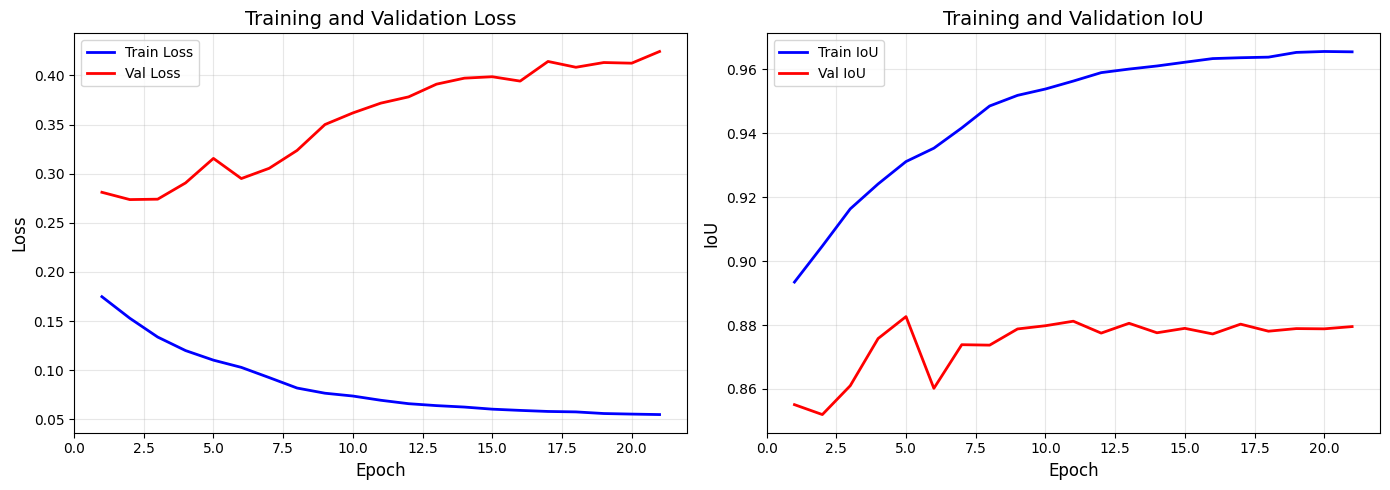

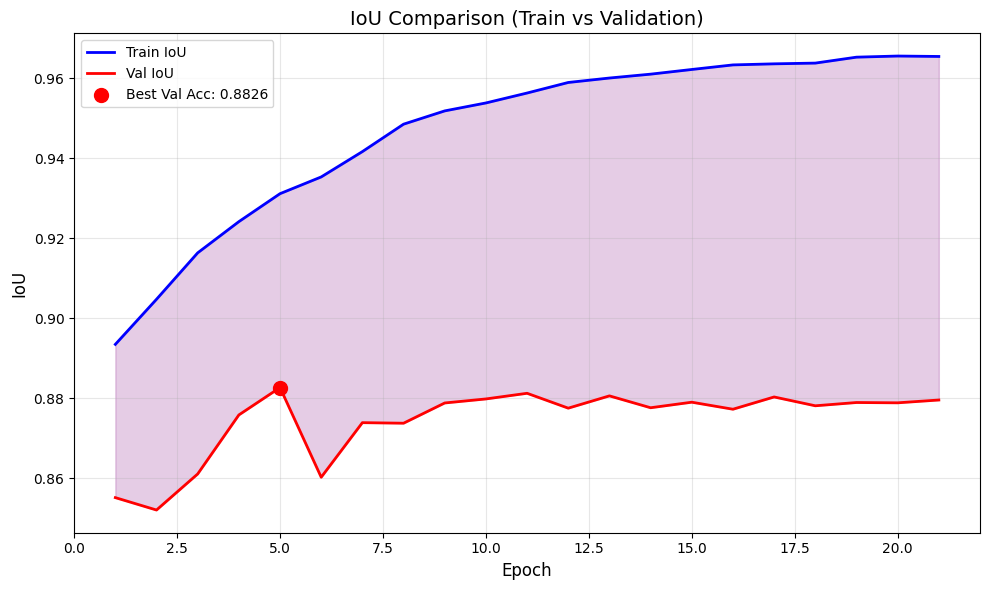

In [27]:
plot_metrics(unet_history_multi_transfer_unfrozen)

In [28]:
df_history = pd.DataFrame(unet_history_multi_transfer_unfrozen)
df_history.to_csv(f'/content/drive/MyDrive/Segmentation project/unet_history_multi_transfer_unfrozen.csv', index_label='epoch')

In [29]:
drive.flush_and_unmount()

runtime.unassign()

## Results

In [54]:
def show_result(model, dataset, seed=42):
    random.seed(seed)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    rand_idx = random.randint(0, len(dataset))

    model.eval()
    with torch.no_grad():
        image, mask = dataset[rand_idx]
        image, mask = image.unsqueeze(0), mask.unsqueeze(0)
        logits = model(image)
        preds = (logits.softmax(dim=1).argmax(dim=1)).float()
        # batch_metrics = compute_metrics(preds, mask, threshold=0.5)
        # print(f'IoU: {batch_metrics['IoU']:.4f}, Dice: {batch_metrics['Dice']:.4f}')

        image_show = (image[0] * STD + MEAN).permute(1, 2, 0)
        ax1.imshow(image_show)
        ax2.imshow(mask.permute(1, 2, 0))
        ax3.imshow(preds.permute(1, 2, 0))

In [14]:
def get_best_metrics(history, key_metric='val_IoU_animal'):
    best_idx = 0
    best_metric = 0

    for i in range(len(history[key_metric])):
        if history[key_metric][i] > best_metric:
            best_metric = history[key_metric][i]
            best_idx = i


    return history.iloc[best_idx][['epoch', 'val_IoU_animal', 'val_IoU_background', 'val_IoU_boundary']]

In [61]:
df_base = pd.read_csv(
    '/content/drive/MyDrive/Segmentation project/unet_stupid_history_multi.csv'
)
df_unet = pd.read_csv(
    '/content/drive/MyDrive/Segmentation project/unet_history_multi.csv'
)
df_transfer = pd.read_csv(
    '/content/drive/MyDrive/Segmentation project/unet_history_multi_transfer_unfrozen.csv'
)



In [62]:
base = pd.DataFrame({'Base': get_best_metrics(df_base).to_dict()})
unet = pd.DataFrame({'U-Net': get_best_metrics(df_unet).to_dict()})
transfer = pd.DataFrame({'ResNet': get_best_metrics(df_transfer).to_dict()})

result = pd.concat([base, unet, transfer], axis=1)

result = result.round(3)

In [19]:
model_base = StupidUNet(n_channels=3, n_classes=3).to(device)
model_unet = UNet(n_channels=3, n_classes=3).to(device)
model_resnet = UNetResNet(n_channels=3, n_classes=3).to(device)


model_base.load_state_dict(torch.load(
    '/content/drive/MyDrive/Segmentation project/best_model_stupid_multi.pt.pt',
    map_location=torch.device('cpu')
))

model_unet.load_state_dict(torch.load(
    '/content/drive/MyDrive/Segmentation project/best_model_multi.pt',
    map_location=torch.device('cpu')
))

model_resnet.load_state_dict(torch.load(
    '/content/drive/MyDrive/Segmentation project/best_model_multi_transfer_unfrozen.pt',
    map_location=torch.device('cpu')
))

<All keys matched successfully>

Stupid U-Net


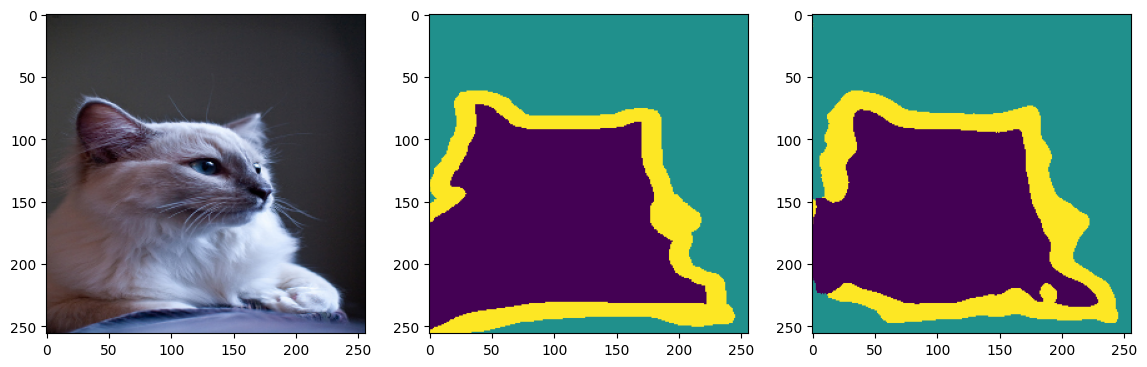

In [55]:
print("Stupid U-Net")
show_result(model_base, test_dataset_multi)

U-Net


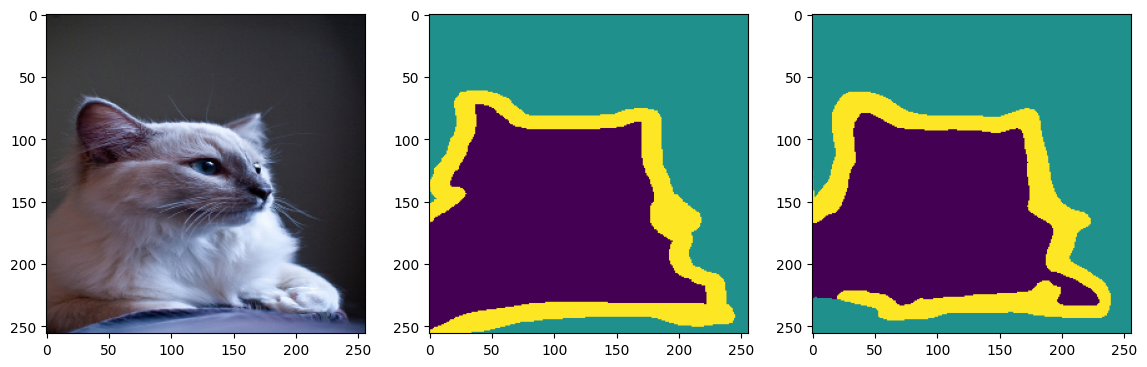

In [56]:
print("U-Net")
show_result(model_unet, test_dataset_multi)

ResNet + U-Net


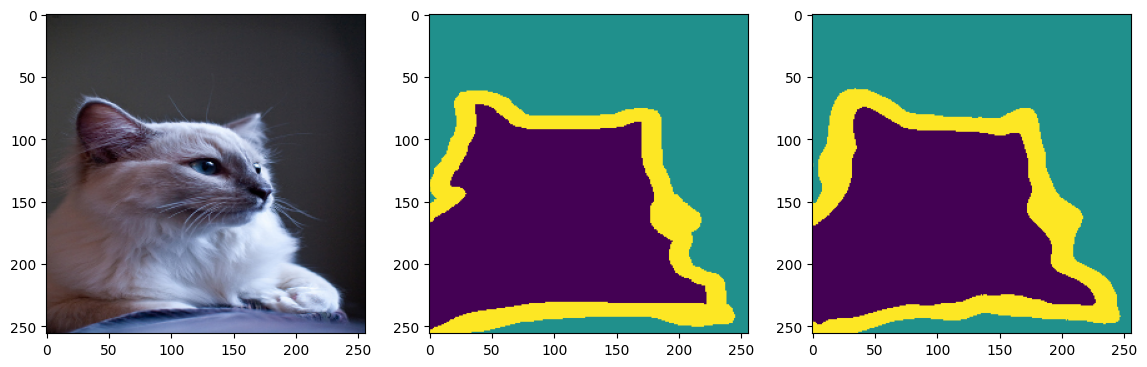

In [58]:
print("ResNet + U-Net")
show_result(model_resnet, test_dataset_multi)

In [63]:
result

,Base,U-Net,ResNet
epoch,17.000,14.000,4.000
val_IoU_animal,0.789,0.808,0.883
val_IoU_background,0.884,0.896,0.935
val_IoU_boundary,0.476,0.493,0.577
